In [15]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import SLSQP
from qiskit_aer.primitives import Estimator as AerEstimator

In [16]:
# Bond lengths in Angstroms (approximate/theoretical for heavier elements)
bond_data = {
    'C':  {'single': 1.54, 'double': 1.34, 'triple': 1.20, 'xh': 1.09}, # C-H varies slightly, using avg
    'Si': {'single': 2.32, 'double': 2.15, 'triple': 2.05, 'xh': 1.48},
    'Ge': {'single': 2.40, 'double': 2.23, 'triple': 2.15, 'xh': 1.53},
    'Sn': {'single': 2.80, 'double': 2.59, 'triple': 2.60, 'xh': 1.70}, # Sn triple bonds are rare/unstable
}

def get_ethane_geometry(atom, d_xx, d_xh):
    # X2H6 Staggered (Same as before)
    z_offset = d_xx / 2.0
    sin_t = np.sqrt(8)/3
    cos_t = 1.0/3.0
    h_z = d_xh * cos_t
    h_r = d_xh * sin_t
    
    coords = [f"{atom} 0.0 0.0 {z_offset}", f"{atom} 0.0 0.0 {-z_offset}"]
    
    # Top H (0, 120, 240)
    for ang in [0, 2*np.pi/3, 4*np.pi/3]:
        coords.append(f"H {h_r*np.cos(ang):.4f} {h_r*np.sin(ang):.4f} {z_offset + h_z:.4f}")
        
    # Bottom H (Staggered: 60, 180, 300)
    for ang in [np.pi/3, np.pi, 5*np.pi/3]:
        coords.append(f"H {h_r*np.cos(ang):.4f} {h_r*np.sin(ang):.4f} {-z_offset - h_z:.4f}")

    return "; ".join(coords)

def get_ethene_geometry(atom, d_xx, d_xh):
    # X2H4 Planar (Same as before)
    z_offset = d_xx / 2.0
    h_x = d_xh * np.sin(np.pi/3) # 60 deg from Z
    h_z = d_xh * np.cos(np.pi/3)
    
    return "; ".join([
        f"{atom} 0.0 0.0 {z_offset}", f"{atom} 0.0 0.0 {-z_offset}",
        f"H {h_x:.4f} 0.0 {z_offset + h_z:.4f}", f"H {-h_x:.4f} 0.0 {z_offset + h_z:.4f}",
        f"H {h_x:.4f} 0.0 {-z_offset - h_z:.4f}", f"H {-h_x:.4f} 0.0 {-z_offset - h_z:.4f}"
    ])

def get_ethyne_geometry(atom, d_xx, d_xh):
    # X2H2 Linear Conformation (H-X=X-H) along Z-axis
    z_x = d_xx / 2.0
    z_h = z_x + d_xh
    
    return "; ".join([
        f"{atom} 0.0 0.0 {z_x}",    # Top Atom
        f"{atom} 0.0 0.0 {-z_x}",   # Bottom Atom
        f"H 0.0 0.0 {z_h}",         # Top H
        f"H 0.0 0.0 {-z_h}"         # Bottom H
    ])

In [17]:
def solve_molecule(label, geometry, basis='sto-3g', n_e=16, n_o=16):
    print(f"--- Processing {label} ({n_e}e, {n_o}o) ---")
    
    driver = PySCFDriver(atom=geometry, basis=basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()
    
    # Transformer Logic
    # 1. Freeze Core (removes deep inner shells)
    # 2. Active Space (selects specific valence orbitals)
    transformers = [
        FreezeCoreTransformer(remove_orbitals=[]),
        ActiveSpaceTransformer(num_electrons=n_e, num_spatial_orbitals=n_o)
    ]
    
    problem_reduced = problem
    for t in transformers:
        problem_reduced = t.transform(problem_reduced)
        
    mapper = JordanWignerMapper()
    
    # VQE Setup
    ansatz = UCCSD(
        problem_reduced.num_spatial_orbitals,
        problem_reduced.num_particles,
        mapper,
        initial_state=HartreeFock(
            problem_reduced.num_spatial_orbitals,
            problem_reduced.num_particles,
            mapper
        )
    )
    
    # Optimization
    start_time = time.time()
    estimator = AerEstimator(approximation=True)
    vqe = VQE(estimator, ansatz, SLSQP(maxiter=50))
    calc = GroundStateEigensolver(mapper, vqe)
    res = calc.solve(problem_reduced)
    end_time = time.time()
    
    return {
        "Molecule": label,
        "Energy (Hartree)": res.total_energies[0],
        "Time (s)": end_time - start_time,
        "Active Space": f"({n_e}e, {n_o}o)"
    }

In [18]:
results = []
atoms = ['C']#, 'Si', 'Ge', 'Sn']

for atom in atoms:
    params = bond_data[atom]
    
    # 1. X2H6 (Ethane-like) -> Single Bond -> (2e, 2o)
    geo_6 = get_ethane_geometry(atom, params['single'], params['xh'])
    try:
        results.append(solve_molecule(f"{atom}2H6", geo_6, n_e=6, n_o=6))
    except Exception as e: print(f"Fail {atom}2H6: {e}")

    # 2. X2H4 (Ethene-like) -> Double Bond -> (4e, 4o)
    geo_4 = get_ethene_geometry(atom, params['double'], params['xh'])
    try:
        results.append(solve_molecule(f"{atom}2H4", geo_4, n_e=6, n_o=6))
    except Exception as e: print(f"Fail {atom}2H4: {e}")
        
    # 3. X2H2 (Ethyne-like) -> Triple Bond -> (6e, 6o)
    geo_2 = get_ethyne_geometry(atom, params['triple'], params['xh'])
    try:
        results.append(solve_molecule(f"{atom}2H2", geo_2, n_e=6, n_o=6))
    except Exception as e: print(f"Fail {atom}2H2: {e}")

# Tabulate
df_results = pd.DataFrame(results)
print("\n=== Comprehensive Results ===")
display(df_results)

--- Processing C2H6 (6e, 6o) ---
--- Processing C2H4 (6e, 6o) ---
--- Processing C2H2 (6e, 6o) ---

=== Comprehensive Results ===


,Molecule,Energy (Hartree),Time (s),Active Space
0,C2H6,-78.305774,2376.389524,"(6e, 6o)"
1,C2H4,-77.070971,1384.348058,"(6e, 6o)"
2,C2H2,-75.904945,4055.980484,"(6e, 6o)"


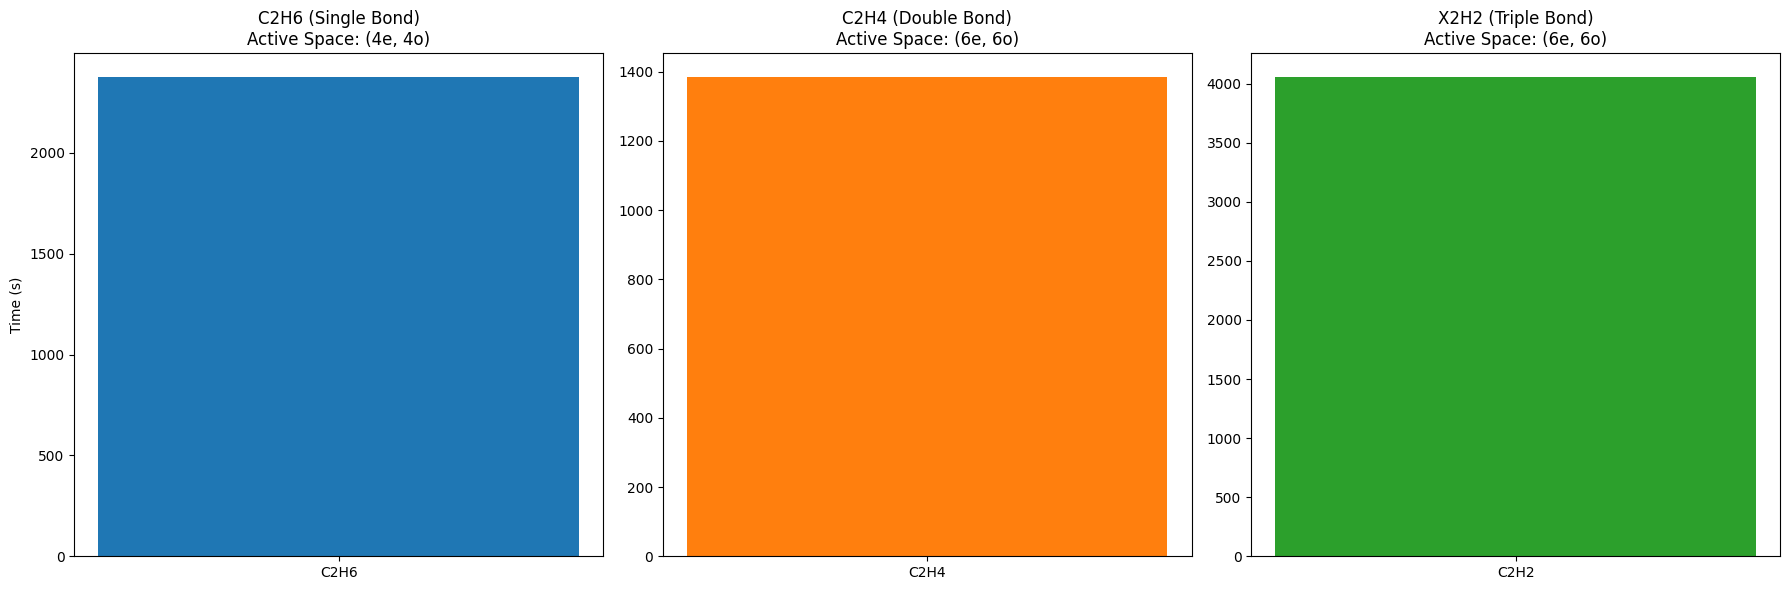

In [19]:
# Filter Data
df_6 = df_results[df_results['Molecule'].str.endswith('H6')]
df_4 = df_results[df_results['Molecule'].str.endswith('H4')]
df_2 = df_results[df_results['Molecule'].str.endswith('H2')]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: X2H6
ax1.bar(df_6['Molecule'], df_6['Time (s)'], color='#1f77b4') # Blue
ax1.set_title('C2H6 (Single Bond)\nActive Space: (4e, 4o)')
ax1.set_ylabel('Time (s)')

# Plot 2: X2H4
ax2.bar(df_4['Molecule'], df_4['Time (s)'], color='#ff7f0e') # Orange
ax2.set_title('C2H4 (Double Bond)\nActive Space: (6e, 6o)')

# Plot 3: X2H2
ax3.bar(df_2['Molecule'], df_2['Time (s)'], color='#2ca02c') # Green
ax3.set_title('X2H2 (Triple Bond)\nActive Space: (6e, 6o)')

plt.tight_layout()
plt.show()